# 0. Dependencies and Helpers

## Dependencies

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import functional as F_v2
from torchvision.tv_tensors import Mask as TVMask

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Helpers

In [ ]:
data_path = '/content/dataset/images/'
mask_path = '/content/dataset/annotations/trimaps/'
annote_path = '/content/dataset/annotations/list.txt'
checkpoint_path = '/content/drive/MyDrive/LABWORKS/CSE428/Project/'

In [ ]:
def imshow_util(img):
    if img.ndim == 3: img = img.permute(1, 2, 0).numpy()
    else: img = img.numpy().unsqueeze()
    return img

In [ ]:
def calculate_seg_metrics(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    FP = ((1 - targets) * preds).sum()
    FN = (targets * (1 - preds)).sum()
    TN = ((1 - targets) * (1 - preds)).sum()

    pixel_acc = (TP + TN + smooth) / (TP + TN + FP + FN + smooth)
    iou = (TP + smooth) / (TP + FP + FN + smooth)
    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)

    return pixel_acc.item(), iou.item(), dice.item()

In [ ]:
def calculate_cls_metrics(predictions, targets):
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.detach().cpu().numpy()
    if isinstance(targets, torch.Tensor):
        targets = targets.detach().cpu().numpy()

    if predictions.ndim > 1 and predictions.shape[-1] > 1:
        predictions = np.argmax(predictions, axis=-1)
    elif predictions.ndim > 1 and predictions.shape[-1] == 1:
        predictions = (predictions.squeeze(-1) > 0.5).astype(int)
    else:
        predictions = (predictions > 0.5).astype(int)

    targets = targets.astype(int)
    predictions = predictions.flatten()
    targets = targets.flatten()

    accuracy = accuracy_score(targets, predictions)
    precision = precision_score(targets, predictions, average='weighted', zero_division=0)
    recall = recall_score(targets, predictions, average='weighted', zero_division=0)
    f1 = f1_score(targets, predictions, average='weighted', zero_division=0)

    return accuracy, precision, recall, f1

In [ ]:
def load_model(model_name, model_instance, optimizer_instance, checkpoint_path=checkpoint_path):
    full_checkpoint_path = checkpoint_path + model_name + '_checkpoint'
    if os.path.exists(full_checkpoint_path):
        checkpoint = torch.load(full_checkpoint_path, map_location=torch.device(device))
        model_instance.load_state_dict(checkpoint['model_state_dict'])
        optimizer_instance.load_state_dict(checkpoint['optimizer_state_dict'])
        loaded_history = {
            'train_losses': checkpoint.get('train_losses', []),
            'val_losses': checkpoint.get('val_losses', []),
            'val_pixel_accs': checkpoint.get('val_pixel_accs', []),
            'val_ious': checkpoint.get('val_ious', []),
            'val_dices': checkpoint.get('val_dices', []),
            'train_accuracies': checkpoint.get('train_accuracies', []),
            'train_precisions': checkpoint.get('train_precisions', []),
            'train_recalls': checkpoint.get('train_recalls', []),
            'train_f1_scores': checkpoint.get('train_f1_scores', []),
            'val_accuracies': checkpoint.get('val_accuracies', []),
            'val_precisions': checkpoint.get('val_precisions', []),
            'val_recalls': checkpoint.get('val_recalls', []),
            'val_f1_scores': checkpoint.get('val_f1_scores', [])
        }
        return model_instance, loaded_history

In [ ]:
def plot_training_metrics(history, title_prefix=""):
    epochs = range(1, len(history['train_losses']) + 1)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_losses'], label='Train Loss')
    plt.plot(epochs, history['val_losses'], label='Validation Loss')
    plt.title(f'{title_prefix}Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['val_pixel_accs'], label='Validation Pixel Accuracy')
    plt.plot(epochs, history['val_ious'], label='Validation IoU')
    plt.plot(epochs, history['val_dices'], label='Validation Dice Coefficient')
    plt.title(f'{title_prefix}Validation Segmentation Metrics')
    plt.xlabel('Epochs')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_accuracies'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracies'], label='Validation Accuracy')
    plt.plot(epochs, history['train_precisions'], label='Train Precision')
    plt.plot(epochs, history['val_precisions'], label='Validation Precision')
    plt.plot(epochs, history['train_recalls'], label='Train Recall')
    plt.plot(epochs, history['val_recalls'], label='Validation Recall')
    plt.plot(epochs, history['train_f1_scores'], label='Train F1-Score')
    plt.plot(epochs, history['val_f1_scores'], label='Validation F1-Score')
    plt.title(f'{title_prefix}Training and Validation Classification Metrics')
    plt.xlabel('Epochs')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def breed_to_species(breed_id):
    if breed_id in [0, 5, 6, 7, 9, 11, 20, 23, 26, 27, 32, 33]: return 0
    else: return 1

In [ ]:
def visualize_prediction(index, model):
    data = dataset[index]
    img_original = data['img']
    mask_actual = data['mask']
    breed_id_actual = data['breed']
    species_id_actual = data['species']

    img_for_model = img_original.to(device).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        seg_output_logits, cls_output_logits = model(img_for_model)

    predicted_mask_probs = torch.sigmoid(seg_output_logits)
    predicted_mask_binary = (predicted_mask_probs > 0.5).float()
    predicted_mask_display = predicted_mask_binary.squeeze(0).cpu()

    predicted_breed_id = torch.argmax(cls_output_logits, dim=1).item()
    predicted_species_id = breed_to_species(predicted_breed_id)

    _, iou, _ = calculate_seg_metrics(seg_output_logits.squeeze(0).cpu(), mask_actual.cpu())

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    cmap = ListedColormap(['#00000000', '#00FF00'])

    overall_title = (
        f"Original Class: {class_id_to_breed[breed_id_actual]} ({species_id_to_species[species_id_actual]})\n"
        f"Predicted Class: {class_id_to_breed[predicted_breed_id]} ({species_id_to_species[predicted_species_id]})\n"
        f"IoU: {iou:.2f}%"
    )
    fig.suptitle(overall_title, fontsize=16, y=1.02)

    axes[0].imshow(imshow_util(img_original))
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(imshow_util(img_original))
    axes[1].imshow(imshow_util(mask_actual), alpha=0.3, cmap=cmap)
    axes[1].set_title("Image+True Mask Overlay")
    axes[1].axis('off')

    axes[2].imshow(imshow_util(img_original))
    axes[2].imshow(imshow_util(predicted_mask_display), alpha=0.3, cmap=cmap)
    axes[2].set_title("Image+Predicted Class Overlay")
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 1.1. Load Dataset into Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# !wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz -P /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset
# !wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz -P /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset

In [ ]:
# !tar -xzf /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset/images.tar.gz -C /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset/
# !tar -xzf /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset/annotations.tar.gz -C /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset/

# 1.2. Load Dataset from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/LABWORKS/CSE428/Project/dataset /content/

# 2. Data Mapping

In [ ]:
class_id_to_breed = {
    0: "Abyssinian",
    1: "American Bulldog",
    2: "American Pit Bull Terrier",
    3: "Basset Hound",
    4: "Beagle",
    5: "Bengal",
    6: "Birman",
    7: "Bombay",
    8: "Boxer",
    9: "British Shorthair",
    10: "Chihuahua",
    11: "Egyptian Mau",
    12: "English Cocker Spaniel",
    13: "English Setter",
    14: "German Shorthaired",
    15: "Great Pyrenees",
    16: "Havanese",
    17: "Japanese Chin",
    18: "Keeshond",
    19: "Leonberger",
    20: "Maine Coon",
    21: "Miniature Pinscher",
    22: "Newfoundland",
    23: "Persian",
    24: "Pomeranian",
    25: "Pug",
    26: "Ragdoll",
    27: "Russian Blue",
    28: "Saint Bernard",
    29: "Samoyed",
    30: "Scottish Terrier",
    31: "Shiba Inu",
    32: "Siamese",
    33: "Sphynx",
    34: "Staffordshire Bull Terrier",
    35: "Wheaten Terrier",
    36: "Yorkshire Terrier"
}

species_id_to_species = {0: 'Cat',
                         1: 'Dog'}

# 3. Compiling Data

In [ ]:
image_data = []

with open(annote_path, 'r') as f:
    annotations_content = f.read()

annotations_split = annotations_content.split('\n')[7:-1]

# filename, class_id, cat/dog, breed_id(ignore)
for i in annotations_split:
    filename, class_id, species_id = i.split()[:3]
    class_id, species_id = int(class_id)-1, int(species_id)-1

    image_data.append({'filename': filename,
                       'filepath': data_path + filename + '.jpg',
                       'maskpath': mask_path + filename + '.png',
                       'breed': class_id,
                       'species': species_id,})

image_data[50:52]

[{'filename': 'american_bulldog_101',
  'filepath': '/content/dataset/images/american_bulldog_101.jpg',
  'maskpath': '/content/dataset/annotations/trimaps/american_bulldog_101.png',
  'breed': 1,
  'species': 1},
 {'filename': 'american_bulldog_102',
  'filepath': '/content/dataset/images/american_bulldog_102.jpg',
  'maskpath': '/content/dataset/annotations/trimaps/american_bulldog_102.png',
  'breed': 1,
  'species': 1}]

In [ ]:
df = pd.DataFrame(image_data)
df.head()

,filename,filepath,maskpath,breed,species
0,Abyssinian_101,/content/dataset/images/Abyssinian_101.jpg,/content/dataset/annotations/trimaps/Abyssinia...,0,0
1,Abyssinian_102,/content/dataset/images/Abyssinian_102.jpg,/content/dataset/annotations/trimaps/Abyssinia...,0,0
2,Abyssinian_103,/content/dataset/images/Abyssinian_103.jpg,/content/dataset/annotations/trimaps/Abyssinia...,0,0
3,Abyssinian_104,/content/dataset/images/Abyssinian_104.jpg,/content/dataset/annotations/trimaps/Abyssinia...,0,0
4,Abyssinian_105,/content/dataset/images/Abyssinian_105.jpg,/content/dataset/annotations/trimaps/Abyssinia...,0,0


In [ ]:
TARGET_IMG_SIZE = (256, 256)

class MyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row['filepath']).convert('RGB')
        mask = Image.open(row['maskpath'])

        img = img.resize(TARGET_IMG_SIZE, Image.BICUBIC)
        mask = mask.resize(TARGET_IMG_SIZE, Image.NEAREST)

        mask_np = np.array(mask, dtype=np.float32)

        # remapping to 0->background[2] 1->foreground[1,3]
        mask_np[mask_np == 2] = 0
        mask_np[(mask_np == 1) | (mask_np == 3)] = 1
        mask_tv = TVMask(torch.tensor(mask_np, dtype=torch.uint8).unsqueeze(0))

        if self.transform:
            transformed_img, transformed_mask = self.transform(img, mask_tv)
            transformed_mask = transformed_mask.float()
        else:
            transformed_img = F_v2.to_image(img)
            transformed_img = F_v2.convert_image_dtype(transformed_img, torch.float32)
            transformed_mask = torch.tensor(mask_np, dtype=torch.float32).unsqueeze(0)

        return {
            "img": transformed_img,
            "mask": transformed_mask,
            "breed": row['breed'],
            "species": row['species'],
            "filename": row['filename']
        }

In [ ]:
dataset = MyDataset(df)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

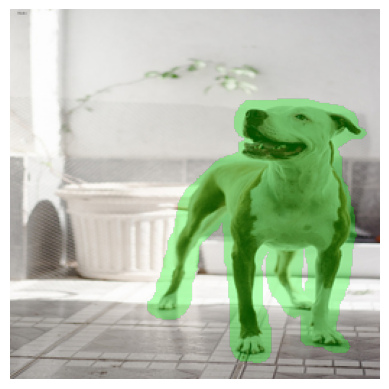

In [ ]:
image_tensor = imshow_util(dataset[99]['img'])
mask_tensor = imshow_util(dataset[99]['mask'])

plt.imshow(image_tensor)

cmap = ListedColormap(['#00000000', '#00FF00'])
plt.imshow(mask_tensor, alpha=0.3, cmap=cmap)

plt.axis('off')

# 4.1. EDA

## Showing data with mask overlay

In [ ]:
rand_idxs = [random.randint(0, len(dataset)) for i in range(9)]

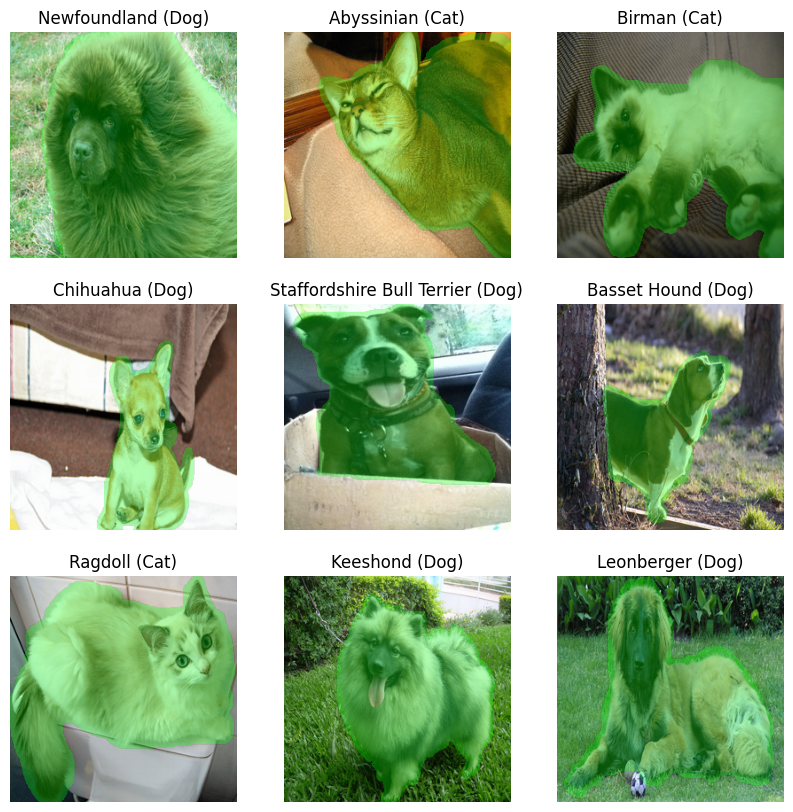

In [ ]:
fig, axes  = plt.subplots(3, 3, figsize = (10, 10))
x, y = 0, 0

for i in range(len(rand_idxs)):
    data = dataset[rand_idxs[i]]
    cmap = ListedColormap(['#00000000', '#00FF00'])

    axes[x, y].imshow(imshow_util(data['img']))
    axes[x, y].imshow(imshow_util(data['mask']), alpha=0.3, cmap=cmap)
    axes[x, y].set_title(f"{class_id_to_breed[data["breed"]]} ({species_id_to_species[data["species"]]})")
    axes[x, y].axis('off')

    y += 1
    if y == 3:
        x += 1
        y = 0

## Foreground Ratio

In [ ]:
total_pixels = 256*256
ratio_dist = []

for i in range(len(dataset)):
    mask = dataset[i]['mask'].numpy()
    ratio = np.sum(mask)/total_pixels
    ratio_dist.append(ratio)

ratio_dist = np.array(ratio_dist)

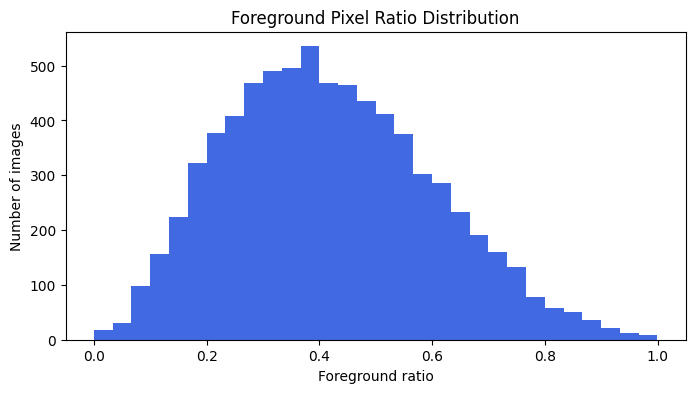

Mean foreground ratio: 0.418
Min foreground ratio: 0.000
Max foreground ratio: 0.999


In [ ]:
plt.figure(figsize = (8, 4))
plt.hist(ratio_dist, bins = 30, color = 'royalblue')
plt.title('Foreground Pixel Ratio Distribution')
plt.xlabel("Foreground ratio")
plt.ylabel("Number of images")
plt.show()

print(f'Mean foreground ratio: {ratio_dist.mean():.3f}')
print(f'Min foreground ratio: {ratio_dist.min():.3f}')
print(f'Max foreground ratio: {ratio_dist.max():.3f}')

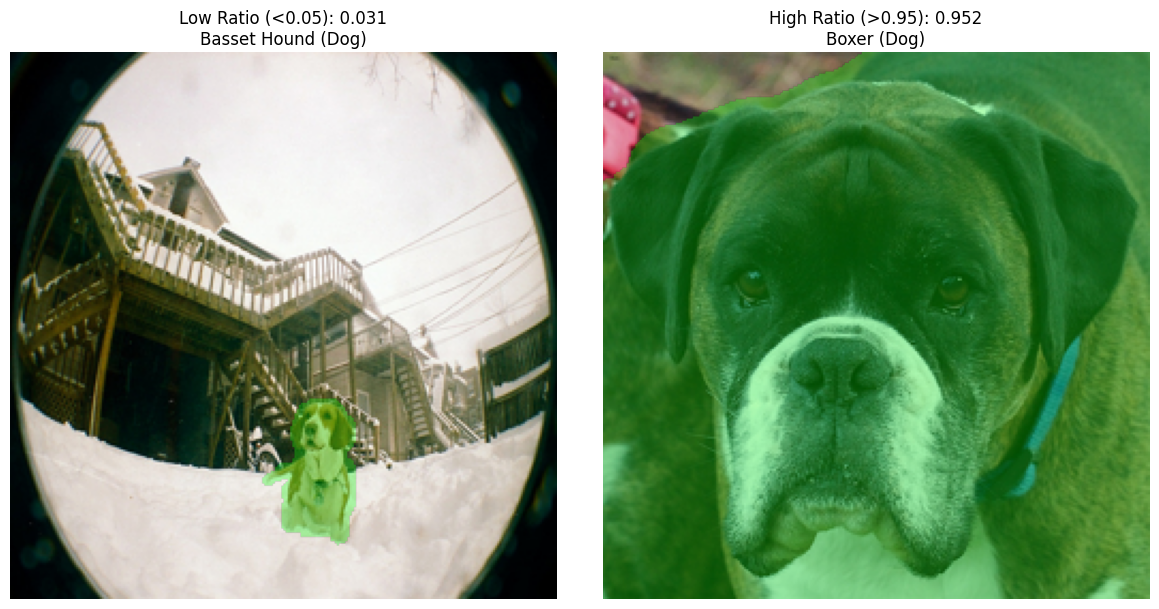

In [ ]:
low_ratio_indices = np.where(ratio_dist < 0.05)[0]
high_ratio_indices = np.where(ratio_dist > 0.95)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
cmap = ListedColormap(['#00000000', '#00FF00'])

sample_idx_low = random.choice(low_ratio_indices)
data_low = dataset[sample_idx_low]
axes[0].imshow(imshow_util(data_low['img']))
axes[0].imshow(imshow_util(data_low['mask']), alpha=0.3, cmap=cmap)
axes[0].set_title(f"Low Ratio (<0.05): {ratio_dist[sample_idx_low]:.3f}\n{class_id_to_breed[data_low['breed']]} ({species_id_to_species[data_low['species']]})")
axes[0].axis('off')

sample_idx_high = random.choice(high_ratio_indices)
data_high = dataset[sample_idx_high]
axes[1].imshow(imshow_util(data_high['img']))
axes[1].imshow(imshow_util(data_high['mask']), alpha=0.3, cmap=cmap)
axes[1].set_title(f"High Ratio (>0.95): {ratio_dist[sample_idx_high]:.3f}\n{class_id_to_breed[data_high['breed']]} ({species_id_to_species[data_high['species']]})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In this analysis, we can see that the graph is a but right skewed. Very low foreground ratio may introduce more noise of background than we expect and very high foreground ratio may confuse the model to expect no background.\
\
We'll address this in data cleaning part of preprocessing.

As this cleaning will influence the following EDA results, we'll do the data cleaning before proceeding with rest of the EDA.

# 5.1. Data Preprocessing

Data cleaning

In [ ]:
all_indices_to_remove = np.concatenate((low_ratio_indices, high_ratio_indices))
cleaned_dataset = df.drop(all_indices_to_remove).reset_index(drop=True)

df = cleaned_dataset.copy()
dataset = MyDataset(df)

print(f"Original database size: {len(all_indices_to_remove) + len(df)}")
print(f"Cleaned database size: {len(df)}")
print(f"Number of entries removed: {len(all_indices_to_remove)}")

Original database size: 7348
Cleaned database size: 7305
Number of entries removed: 43


# 4.2. EDA

## Class distribution

In [ ]:
breed_counts = df['breed'].value_counts().sort_index()

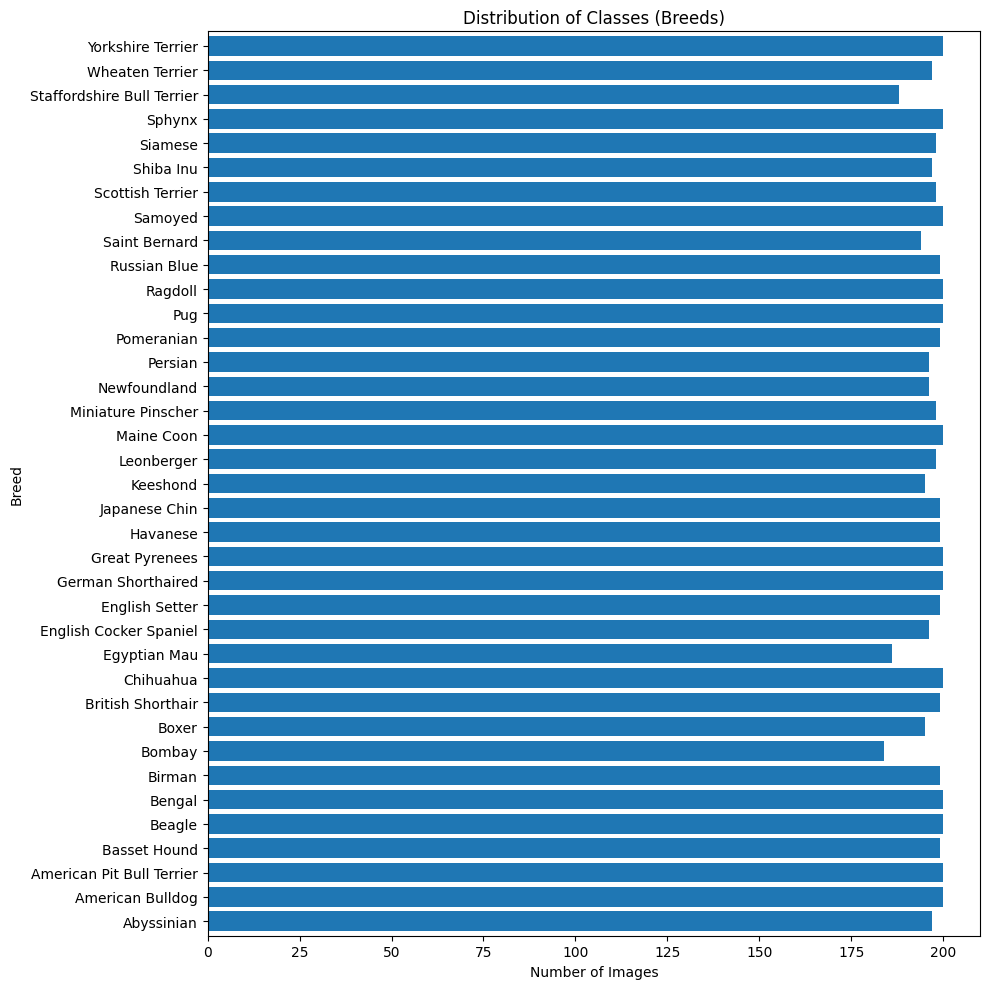


Class Distribution Min: 184
Class Distribution Max: 200


In [ ]:
plt.figure(figsize=(10,10))
plt.barh(breed_counts.index, breed_counts.values)
plt.yticks(breed_counts.index, [class_id_to_breed[i] for i in breed_counts.index])
plt.xlabel('Number of Images')
plt.ylabel('Breed')
plt.title('Distribution of Classes (Breeds)')
plt.gca().invert_yaxis()
plt.ylim(breed_counts.index.min() - 0.6, breed_counts.index.max() + 0.6) # Set y-axis limits to remove gaps
plt.tight_layout()
plt.show()

print()
print(f"Class Distribution Min: {breed_counts.min()}")
print(f"Class Distribution Max: {breed_counts.max()}")

In [ ]:
species_counts = df['species'].value_counts().sort_index()

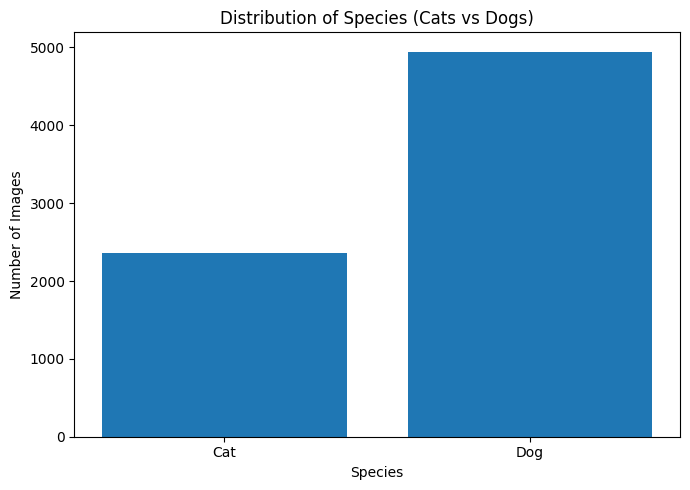

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(species_counts.index, species_counts.values, tick_label=[species_id_to_species[i] for i in species_counts.index])
plt.xlabel('Species')
plt.ylabel('Number of Images')
plt.title('Distribution of Species (Cats vs Dogs)')
plt.tight_layout()
plt.show()

In this analysis, it clearly shows that the breed distribution is fairly well-distributed whereas there's almost half of cat images compared to dogs.\
\
To avoid species class imbalance, we'll use breed to train/predict and then map them to cats or dogs in classification To avoid any bias in breed, we'll use stratification when splitting and use class weights to balance them.\
\
However, the per breed data count is only around 185-200 which is very low. To address this, we will use data augmentation.

# 5.2. Data Preprocessing

## Normalization and Resizing

Normalization and resizing was handled in dataset.\_\_getitem\_\_\
The images were in 0-255 range. For normalization, we divided the pixels by 255.0 to keep it in 0-1 range\
The images had varying sizes. To work with models, we resized them into a standard 256x256 size.

# 6.1 Data Splitting

### Dataframe split

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['breed'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['breed'], random_state=42)

print(f"Total dataset size: {len(df)}")
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Total dataset size: 7305
Training set size: 4090
Validation set size: 1023
Test set size: 2192


# 5.3. Data Preprocessing

## Compute class weights

In [ ]:
classes = np.unique(train_df['breed'])

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['breed']
)

class_weights = torch.tensor(class_weights_array, dtype=torch.float)

## Augmentation

In [ ]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToImage(),
    T.ConvertImageDtype(torch.float32)
])

val_test_transform = T.Compose([
    T.ToImage(),
    T.ConvertImageDtype(torch.float32),
])

# 6.2. Data Splitting

## Dataset split

In [ ]:
train_dataset = MyDataset(train_df, transform=train_transform)
val_dataset = MyDataset(val_df, transform=val_test_transform)
test_dataset = MyDataset(test_df, transform=val_test_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 4090
Validation dataset size: 1023
Test dataset size: 2192


## Data Loader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Number of batches in train_loader: 128
Number of batches in val_loader: 32
Number of batches in test_loader: 69


# 7.1. Model

## U-Net

In [ ]:
# Double convolution block in U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

# Downsampling block (encoder path)
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

# Upsampling block (decoder path)
class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Crop x2 to match the size of x1
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x2 = x2[:, :, diffY // 2 : x2.size()[2] - diffY // 2,
                     diffX // 2 : x2.size()[3] - diffX // 2]

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

# Output convolution layer
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# U-Net Model Definition
class UNet(nn.Module):
    def __init__(self, n_channels=3, n_seg_classes=1, n_breed_classes=37):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_seg_classes = n_seg_classes
        self.n_breed_classes = n_breed_classes

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024) # Last encoder output, used for classifier

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.outc = OutConv(64, n_seg_classes) # Segmentation output

        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1024, n_breed_classes)
        )

    def forward(self, x):
        # Encoder path
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Breed classification branch
        breed_logits = self.classifier(x5)

        # Decoder path (segmentation)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        seg_logits = self.outc(x) # Segmentation output

        return seg_logits, breed_logits

# 8. Model Training Loop



In [ ]:
from tqdm.auto import tqdm

def train_model(model_name, model, train_loader, val_loader, optimizer, loss_func, device, num_epochs, checkpoint_path='best_model_checkpoint.pth'):
    best_val_iou = -1.0
    start_epoch = 0
    checkpoint_path += model_name + '_checkpoint'

    train_losses = []
    val_losses = []
    val_pixel_accs = []
    val_ious = []
    val_dices = []
    train_accuracies = []
    train_precisions = []
    train_recalls = []
    train_f1_scores = []
    val_accuracies = []
    val_precisions = []
    val_recalls = []
    val_f1_scores = []

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_iou = checkpoint['best_val_iou']
        train_losses = checkpoint.get('train_losses', [])
        val_losses = checkpoint.get('val_losses', [])
        val_pixel_accs = checkpoint.get('val_pixel_accs', [])
        val_ious = checkpoint.get('val_ious', [])
        val_dices = checkpoint.get('val_dices', [])
        train_accuracies = checkpoint.get('train_accuracies', [])
        train_precisions = checkpoint.get('train_precisions', [])
        train_recalls = checkpoint.get('train_recalls', [])
        train_f1_scores = checkpoint.get('train_f1_scores', [])
        val_accuracies = checkpoint.get('val_accuracies', [])
        val_precisions = checkpoint.get('val_precisions', [])
        val_recalls = checkpoint.get('val_recalls', [])
        val_f1_scores = checkpoint.get('val_f1_scores', [])
        print(f"Resuming training from epoch {start_epoch} with best validation IoU: {best_val_iou:.4f}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        running_train_loss = 0.0
        train_batch_pixel_acc = 0.0
        train_batch_iou = 0.0
        train_batch_dice = 0.0
        train_batch_accuracy = 0.0
        train_batch_precision = 0.0
        train_batch_recall = 0.0
        train_batch_f1 = 0.0

        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for batch_idx, data in enumerate(train_loader_tqdm):
            inputs = data['img'].to(device)
            masks = data['mask'].to(device)
            breeds = data['breed'].to(device)

            optimizer.zero_grad()
            seg_outputs, cls_outputs = model(inputs)

            seg_loss = loss_func['segmentation'](seg_outputs, masks)
            cls_loss = loss_func['classification'](cls_outputs, breeds)
            loss = seg_loss + cls_loss

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

            pixel_acc, iou, dice = calculate_seg_metrics(seg_outputs, masks)
            train_batch_pixel_acc += pixel_acc
            train_batch_iou += iou
            train_batch_dice += dice

            accuracy, precision, recall, f1 = calculate_cls_metrics(cls_outputs, breeds)
            train_batch_accuracy += accuracy
            train_batch_precision += precision
            train_batch_recall += recall
            train_batch_f1 += f1

            train_loader_tqdm.set_postfix(
                loss=running_train_loss / (batch_idx + 1),
                iou=train_batch_iou / (batch_idx + 1),
                acc=train_batch_accuracy / (batch_idx + 1)
            )

        avg_train_loss = running_train_loss / len(train_loader)
        avg_train_pixel_acc = train_batch_pixel_acc / len(train_loader)
        avg_train_iou = train_batch_iou / len(train_loader)
        avg_train_dice = train_batch_dice / len(train_loader)
        avg_train_accuracy = train_batch_accuracy / len(train_loader)
        avg_train_precision = train_batch_precision / len(train_loader)
        avg_train_recall = train_batch_recall / len(train_loader)
        avg_train_f1_score = train_batch_f1 / len(train_loader)

        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_accuracy)
        train_precisions.append(avg_train_precision)
        train_recalls.append(avg_train_recall)
        train_f1_scores.append(avg_train_f1_score)

        model.eval()
        running_val_loss = 0.0
        total_val_pixel_acc = 0.0
        total_val_iou = 0.0
        total_val_dice = 0.0
        total_val_accuracy = 0.0
        total_val_precision = 0.0
        total_val_recall = 0.0
        total_val_f1 = 0.0

        val_loader_tqdm = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
        with torch.no_grad():
            for batch_idx, data in enumerate(val_loader_tqdm):
                inputs = data['img'].to(device)
                masks = data['mask'].to(device)
                breeds = data['breed'].to(device)

                seg_outputs, cls_outputs = model(inputs)

                seg_loss = loss_func['segmentation'](seg_outputs, masks)
                cls_loss = loss_func['classification'](cls_outputs, breeds)
                loss = seg_loss + cls_loss
                running_val_loss += loss.item()

                pixel_acc, iou, dice = calculate_seg_metrics(seg_outputs, masks)
                total_val_pixel_acc += pixel_acc
                total_val_iou += iou
                total_val_dice += dice

                accuracy, precision, recall, f1 = calculate_cls_metrics(cls_outputs, breeds)
                total_val_accuracy += accuracy
                total_val_precision += precision
                total_val_recall += recall
                total_val_f1 += f1

                val_loader_tqdm.set_postfix(
                    loss=running_val_loss / (batch_idx + 1),
                    iou=total_val_iou / (batch_idx + 1),
                    acc=total_val_accuracy / (batch_idx + 1)
                )

            avg_val_loss = running_val_loss / len(val_loader)
            avg_val_pixel_acc = total_val_pixel_acc / len(val_loader)
            avg_val_iou = total_val_iou / len(val_loader)
            avg_val_dice = total_val_dice / len(val_loader)
            avg_val_accuracy = total_val_accuracy / len(val_loader)
            avg_val_precision = total_val_precision / len(val_loader)
            avg_val_recall = total_val_recall / len(val_loader)
            avg_val_f1_score = total_val_f1 / len(val_loader)

            val_losses.append(avg_val_loss)
            val_pixel_accs.append(avg_val_pixel_acc)
            val_ious.append(avg_val_iou)
            val_dices.append(avg_val_dice)
            val_accuracies.append(avg_val_accuracy)
            val_precisions.append(avg_val_precision)
            val_recalls.append(avg_val_recall)
            val_f1_scores.append(avg_val_f1_score)

        print(f"Epoch {epoch+1}/{num_epochs}:\n"\
              f"\tSegmentation metrics:\n"\
              f"\t\tTrain Loss: {avg_train_loss:.4f} | Train Pixel Acc: {avg_train_pixel_acc:.4f} | Train IoU: {avg_train_iou:.4f} | Train Dice: {avg_train_dice:.4f}\n"\
              f"\t\tVal Loss: {avg_val_loss:.4f} | Val Pixel Acc: {avg_val_pixel_acc:.4f} | Val IoU: {avg_val_iou:.4f} | Val Dice: {avg_val_dice:.4f}\n"\
              f"\tClassification metrics:\n"\
              f"\t\tTrain Acc: {avg_train_accuracy:.4f} | Train Prec: {avg_train_precision:.4f} | Train Recall: {avg_train_recall:.4f} | Train F1: {avg_train_f1_score:.4f}\n"\
              f"\t\tVal Acc: {avg_val_accuracy:.4f} | Val Prec: {avg_val_precision:.4f} | Val Recall: {avg_val_recall:.4f} | Val F1: {avg_val_f1_score:.4f}")

        if avg_val_iou > best_val_iou:
            best_val_iou = avg_val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_iou': best_val_iou,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'val_pixel_accs': val_pixel_accs,
                'val_ious': val_ious,
                'val_dices': val_dices,
                'train_accuracies': train_accuracies,
                'train_precisions': train_precisions,
                'train_recalls': train_recalls,
                'train_f1_scores': train_f1_scores,
                'val_accuracies': val_accuracies,
                'val_precisions': val_precisions,
                'val_recalls': val_recalls,
                'val_f1_scores': val_f1_scores,
            }, checkpoint_path)
            print(f"Model saved! Best validation IoU improved to {best_val_iou:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_pixel_accs': val_pixel_accs,
        'val_ious': val_ious,
        'val_dices': val_dices,
        'train_accuracies': train_accuracies,
        'train_precisions': train_precisions,
        'train_recalls': train_recalls,
        'train_f1_scores': train_f1_scores,
        'val_accuracies': val_accuracies,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }

# 9.1. Model Training

U-Net

In [ ]:
model = UNet().to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

mean_foreground_ratio = 0.418
pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))

loss_func = {
    'segmentation': seg_loss_func,
    'classification': cls_loss_func
}

num_epochs = 30

history_unet = train_model(
    model_name='unet',
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_func=loss_func,
    device=device,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path
)

print("Training complete!")
# The training_logs dictionary now contains 'train_losses', 'val_losses', etc.

Epoch 1/30 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/30:
	Segmentation metrics:
		Train Loss: 4.3900 | Train Pixel Acc: 0.6936 | Train IoU: 0.5089 | Train Dice: 0.6703
		Val Loss: 4.2550 | Val Pixel Acc: 0.7598 | Val IoU: 0.5553 | Val Dice: 0.7135
	Classification metrics:
		Train Acc: 0.0276 | Train Prec: 0.0069 | Train Recall: 0.0276 | Train F1: 0.0084
		Val Acc: 0.0225 | Val Prec: 0.0090 | Val Recall: 0.0225 | Val F1: 0.0078
Model saved! Best validation IoU improved to 0.5553


Epoch 2/30 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 29/30:
	Segmentation metrics:
		Train Loss: 1.1666 | Train Pixel Acc: 0.9090 | Train IoU: 0.8075 | Train Dice: 0.8933
		Val Loss: 2.0349 | Val Pixel Acc: 0.8933 | Val IoU: 0.7864 | Val Dice: 0.8802
	Classification metrics:
		Train Acc: 0.7086 | Train Prec: 0.7621 | Train Recall: 0.7086 | Train F1: 0.7094
		Val Acc: 0.5015 | Val Prec: 0.5525 | Val Recall: 0.5015 | Val F1: 0.4908


Epoch 30/30 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 30/30:
	Segmentation metrics:
		Train Loss: 1.0844 | Train Pixel Acc: 0.9119 | Train IoU: 0.8131 | Train Dice: 0.8967
		Val Loss: 1.8990 | Val Pixel Acc: 0.9140 | Val IoU: 0.8079 | Val Dice: 0.8936
	Classification metrics:
		Train Acc: 0.7338 | Train Prec: 0.7908 | Train Recall: 0.7338 | Train F1: 0.7370
		Val Acc: 0.5259 | Val Prec: 0.5696 | Val Recall: 0.5259 | Val F1: 0.5159
Model saved! Best validation IoU improved to 0.8079
Training complete!


In [ ]:
model_unet = UNet(n_channels=3).to(device)
unet_optimizer = optim.AdamW(model_unet.parameters(), lr=0.001)

model_unet, history_unet = load_model('unet', model_unet, unet_optimizer, checkpoint_path)

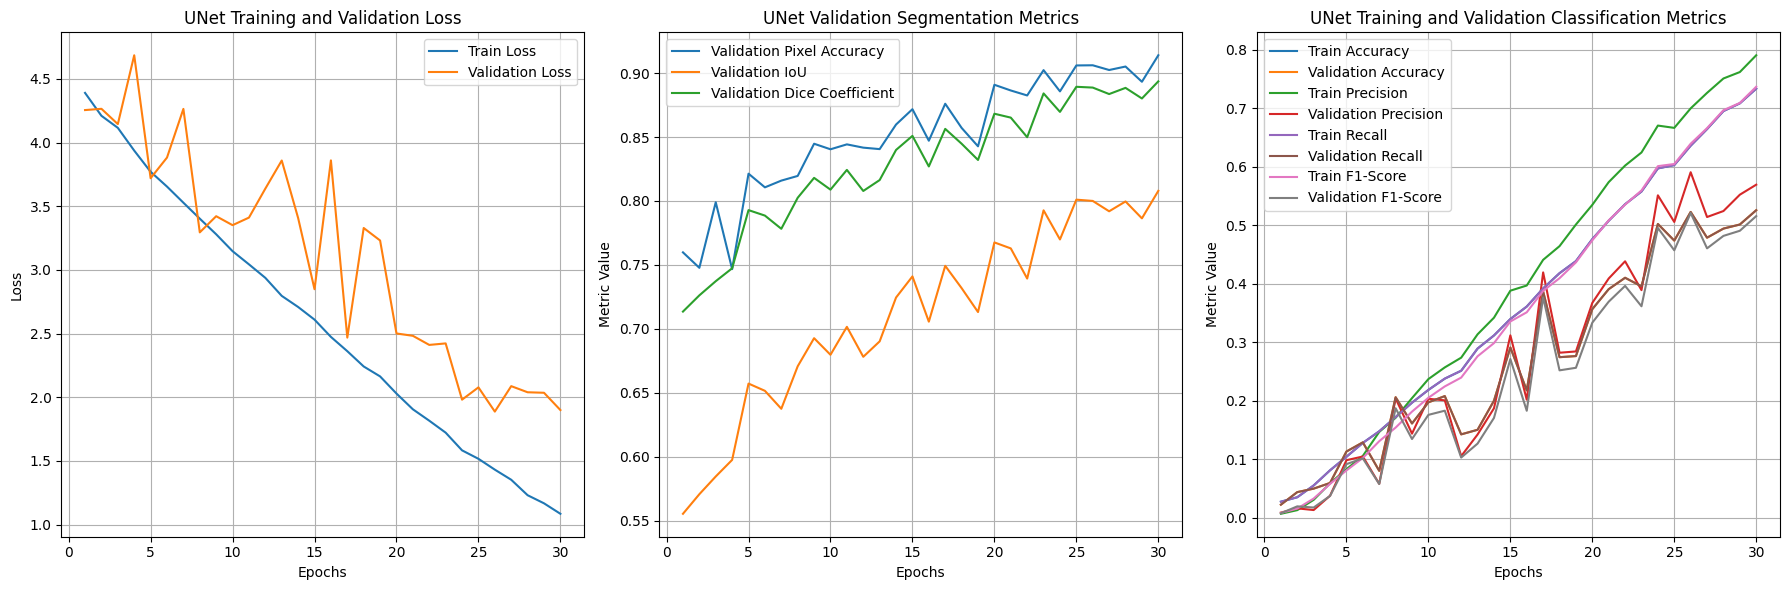

In [ ]:
plot_training_metrics(history_unet, title_prefix="UNet ")

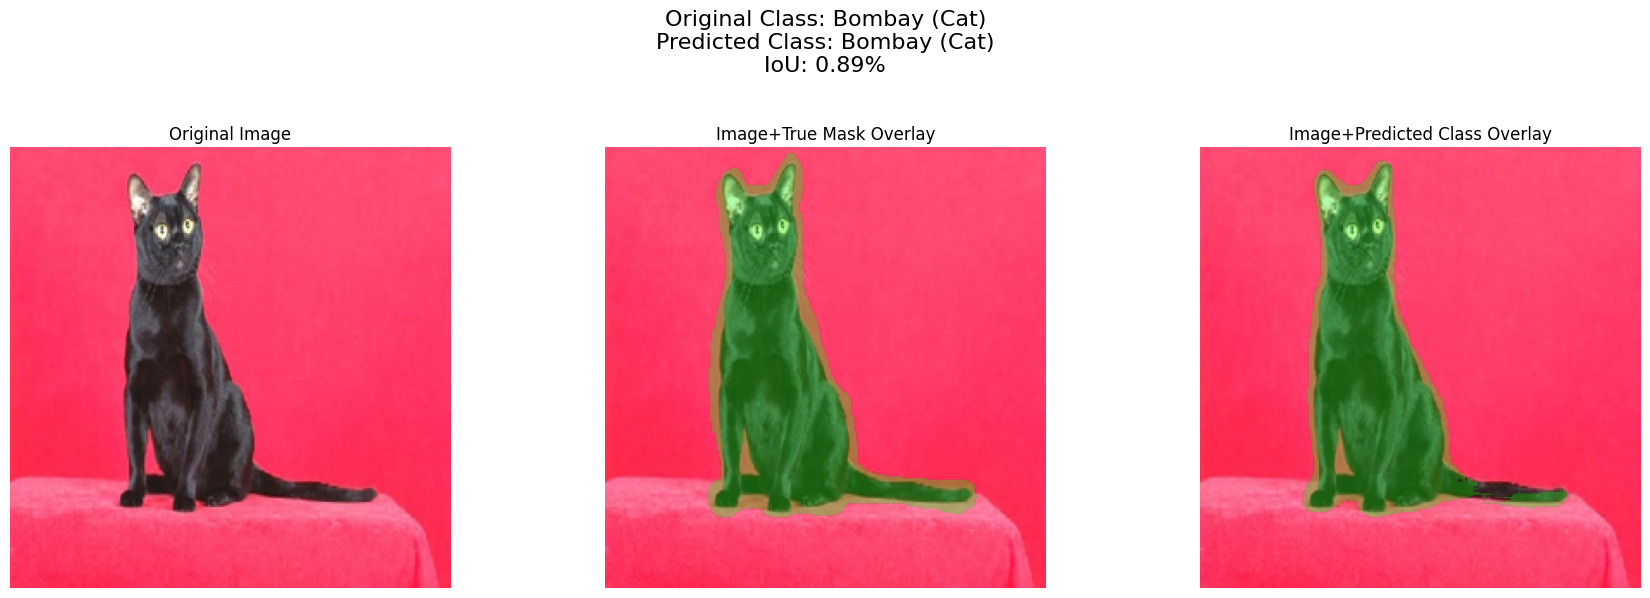

In [ ]:
random_test_idx = random.randint(0, len(test_dataset) - 1)
original_df_index = test_df.index[random_test_idx]

visualize_prediction(original_df_index, model_unet)

In [ ]:
from google.colab import runtime
runtime.unassign()

# 7.2. Model

## Attention U-Net

In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(inter_channels)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(inter_channels)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi_val = self.relu(g1 + x1)
        psi_val = self.psi(psi_val)

        return x * psi_val


# Upsampling block with Attention Gate
class UpAttention(nn.Module):
    def __init__(self, in_channels, out_channels, skip_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)

        self.attention = AttentionGate(g_channels=in_channels // 2, x_channels=skip_channels, inter_channels=skip_channels // 2)

        self.conv = DoubleConv(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x1, x2):
        # x1 is from the previous decoder layer (upsampled by ConvTranspose)
        # x2 is from the corresponding encoder layer (skip connection)
        x1 = self.up(x1)

        # Crop x2 to match the size of x1. This is crucial for concatenation
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x2_cropped = x2[:, :, diffY // 2 : x2.size()[2] - diffY // 2,
                             diffX // 2 : x2.size()[3] - diffX // 2]

        # Apply attention to the cropped skip connection x2 using x1 as gating signal
        x2_att = self.attention(x2_cropped, x1)

        # Concatenate x2_att (attended skip connection) with x1 (upsampled feature map)
        x = torch.cat([x2_att, x1], dim=1)
        return self.conv(x)


# Attention U-Net Model Definition
class AttentionUNet(nn.Module):
    def __init__(self, n_channels=3, n_seg_classes=1, n_breed_classes=37):
        super(AttentionUNet, self).__init__()
        self.n_channels = n_channels
        self.n_seg_classes = n_seg_classes
        self.n_breed_classes = n_breed_classes

        # Encoder path
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024) # Bottleneck, and input for classifier

        # Decoder path with Attention Gates
        self.up1 = UpAttention(1024, 512, 512) # x5 (1024) -> up -> 512; x4 (512) -> AG -> 512; concat 512+512 -> conv 512
        self.up2 = UpAttention(512, 256, 256)   # up1_out (512) -> up -> 256; x3 (256) -> AG -> 256; concat 256+256 -> conv 256
        self.up3 = UpAttention(256, 128, 128)   # up2_out (256) -> up -> 128; x2 (128) -> AG -> 128; concat 128+128 -> conv 128
        self.up4 = UpAttention(128, 64, 64)     # up3_out (128) -> up -> 64; x1 (64) -> AG -> 64; concat 64+64 -> conv 64

        self.outc = OutConv(64, n_seg_classes)

        # Classifier head (attached to the deepest encoder output)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1024, n_breed_classes)
        )

    def forward(self, x):
        # Encoder path
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) # Bottleneck

        # Breed classification branch (from bottleneck output)
        breed_logits = self.classifier(x5)

        # Decoder path (segmentation)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        seg_logits = self.outc(x) # Segmentation output

        return seg_logits, breed_logits

# 9.2. Model Training

## Attention U-Net

In [ ]:
try:
  model_att_unet = AttentionUNet().to(device)

  optimizer_att_unet = optim.AdamW(model_att_unet.parameters(), lr=0.001)

  mean_foreground_ratio = 0.418 # From previous EDA result
  pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
  att_seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

  att_cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))

  att_loss_func = {
      'segmentation': att_seg_loss_func,
      'classification': att_cls_loss_func
  }

  num_epochs = 30

  history_att_unet = train_model(
      model_name='att_unet',
      model=model_att_unet,
      train_loader=train_loader,
      val_loader=val_loader,
      optimizer=optimizer_att_unet,
      loss_func=att_loss_func,
      device=device,
      num_epochs=num_epochs,
      checkpoint_path=checkpoint_path
  )

  print("Attention U-Net Training complete!")
except Exception as e:
    print(f"Code crashed with error: {e}")
    print("Shutting down...")
    os.kill(os.getpid(), 9)

Resuming training from epoch 27 with best validation IoU: 0.8155


Epoch 28/30 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 28/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 28/30:
	Segmentation metrics:
		Train Loss: 1.2031 | Train Pixel Acc: 0.9116 | Train IoU: 0.8122 | Train Dice: 0.8959
		Val Loss: 1.9342 | Val Pixel Acc: 0.8598 | Val IoU: 0.7401 | Val Dice: 0.8497
	Classification metrics:
		Train Acc: 0.6995 | Train Prec: 0.7479 | Train Recall: 0.6995 | Train F1: 0.7072
		Val Acc: 0.5512 | Val Prec: 0.5606 | Val Recall: 0.5512 | Val F1: 0.5396


Epoch 29/30 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 29/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 29/30:
	Segmentation metrics:
		Train Loss: 1.1142 | Train Pixel Acc: 0.9155 | Train IoU: 0.8201 | Train Dice: 0.9008
		Val Loss: 2.1904 | Val Pixel Acc: 0.8783 | Val IoU: 0.7615 | Val Dice: 0.8638
	Classification metrics:
		Train Acc: 0.7155 | Train Prec: 0.7567 | Train Recall: 0.7155 | Train F1: 0.7215
		Val Acc: 0.4974 | Val Prec: 0.5036 | Val Recall: 0.4974 | Val F1: 0.4852


Epoch 30/30 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 30/30:
	Segmentation metrics:
		Train Loss: 1.0709 | Train Pixel Acc: 0.9143 | Train IoU: 0.8175 | Train Dice: 0.8992
		Val Loss: 1.7353 | Val Pixel Acc: 0.9149 | Val IoU: 0.8202 | Val Dice: 0.9009
	Classification metrics:
		Train Acc: 0.7358 | Train Prec: 0.7833 | Train Recall: 0.7358 | Train F1: 0.7431
		Val Acc: 0.5717 | Val Prec: 0.5993 | Val Recall: 0.5717 | Val F1: 0.5656
Model saved! Best validation IoU improved to 0.8202
Attention U-Net Training complete!


In [ ]:
model_att_unet = AttentionUNet().to(device)
optimizer_att_unet = optim.AdamW(model_att_unet.parameters(), lr=0.001)

model_att_unet, history_att_unet = load_model('att_unet', model_att_unet, optimizer_att_unet, checkpoint_path)

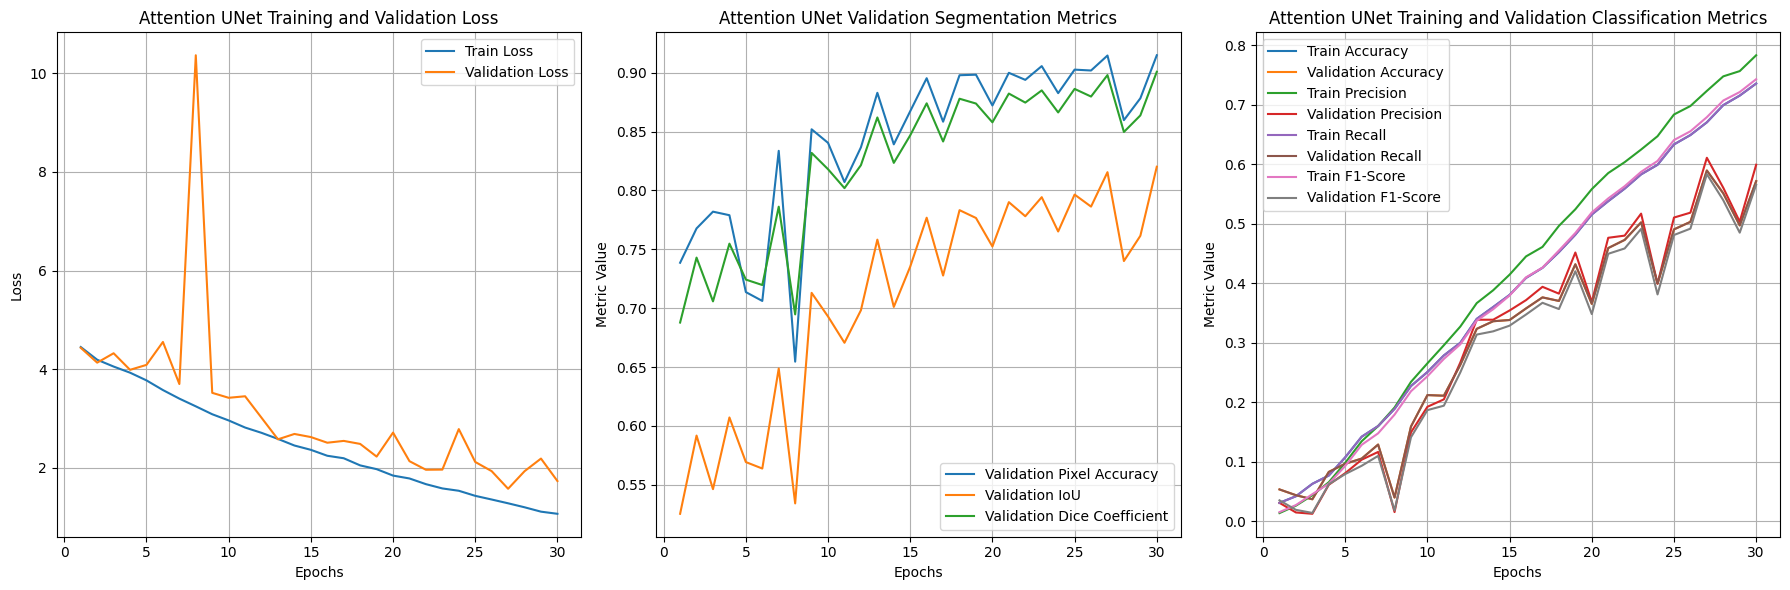

In [ ]:
plot_training_metrics(history_att_unet, title_prefix="Attention UNet ")

Keeshond Dog Keeshond Dog 0.8784783482551575


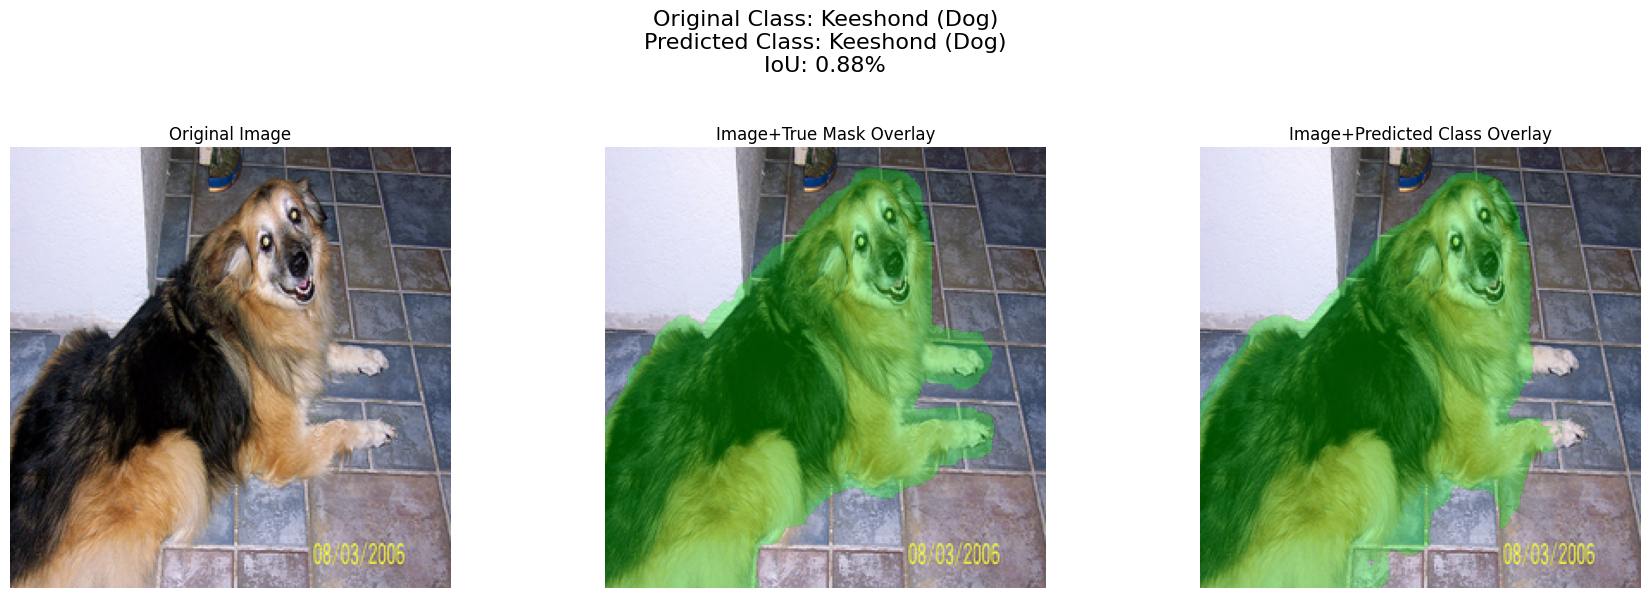

In [ ]:
random_test_idx = random.randint(0, len(test_dataset) - 1)
original_df_index = test_df.index[random_test_idx]

visualize_prediction(original_df_index, model_att_unet)

#10. Testing

In [ ]:
def test_model(model, test_loader, loss_func, device):
    model.eval() # Set model to evaluation mode
    running_test_loss = 0.0
    total_test_pixel_acc = 0.0
    total_test_iou = 0.0
    total_test_dice = 0.0
    total_test_accuracy = 0.0
    total_test_precision = 0.0
    total_test_recall = 0.0
    total_test_f1 = 0.0

    with torch.no_grad(): # Disable gradient calculation
        for batch_idx, data in enumerate(tqdm(test_loader, desc="Testing")):
            inputs = data['img'].to(device)
            masks = data['mask'].to(device)
            breeds = data['breed'].to(device)

            seg_outputs, cls_outputs = model(inputs)

            # Calculate losses for both tasks
            seg_loss = loss_func['segmentation'](seg_outputs, masks)
            cls_loss = loss_func['classification'](cls_outputs, breeds)
            loss = seg_loss + cls_loss # Combined loss
            running_test_loss += loss.item()

            # Segmentation metrics
            pixel_acc, iou, dice = calculate_seg_metrics(seg_outputs, masks)
            total_test_pixel_acc += pixel_acc
            total_test_iou += iou
            total_test_dice += dice

            # Classification metrics
            accuracy, precision, recall, f1 = calculate_cls_metrics(cls_outputs, breeds)
            total_test_accuracy += accuracy
            total_test_precision += precision
            total_test_recall += recall
            total_test_f1 += f1

    avg_test_loss = running_test_loss / len(test_loader)
    avg_test_pixel_acc = total_test_pixel_acc / len(test_loader)
    avg_test_iou = total_test_iou / len(test_loader)
    avg_test_dice = total_test_dice / len(test_loader)
    avg_test_accuracy = total_test_accuracy / len(test_loader)
    avg_test_precision = total_test_precision / len(test_loader)
    avg_test_recall = total_test_recall / len(test_loader)
    avg_test_f1_score = total_test_f1 / len(test_loader)

    print("\n--- Test Results ---")
    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Segmentation Metrics:")
    print(f"  Pixel Accuracy: {avg_test_pixel_acc:.4f}")
    print(f"  IoU: {avg_test_iou:.4f}")
    print(f"  Dice Coefficient: {avg_test_dice:.4f}")
    print(f"Classification Metrics:")
    print(f"  Accuracy: {avg_test_accuracy:.4f}")
    print(f"  Precision: {avg_test_precision:.4f}")
    print(f"  Recall: {avg_test_recall:.4f}")
    print(f"  F1-Score: {avg_test_f1_score:.4f}")

    return {
        'test_loss': avg_test_loss,
        'test_pixel_acc': avg_test_pixel_acc,
        'test_iou': avg_test_iou,
        'test_dice': avg_test_dice,
        'test_accuracy': avg_test_accuracy,
        'test_precision': avg_test_precision,
        'test_recall': avg_test_recall,
        'test_f1_score': avg_test_f1_score
    }

In [ ]:
model_unet = UNet(n_channels=3).to(device)

mean_foreground_ratio = 0.418 # From previous EDA result
pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)
cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))
unet_optimizer = optim.AdamW(model_unet.parameters(), lr=0.001)
loss_func = {
    'segmentation': seg_loss_func,
    'classification': cls_loss_func
}

model_unet, history_unet = load_model('unet', model_unet, unet_optimizer, checkpoint_path)

In [ ]:
model_att_unet = AttentionUNet().to(device)

mean_foreground_ratio = 0.418 # From previous EDA result
pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
att_seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)
att_cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer_att_unet = optim.AdamW(model_att_unet.parameters(), lr=0.001)
att_loss_func = {
    'segmentation': att_seg_loss_func,
    'classification': att_cls_loss_func
}

model_att_unet, history_att_unet = load_model('att_unet', model_att_unet, optimizer_att_unet, checkpoint_path)

In [ ]:
print("Testing UNet Model...")
unet_test_metrics = test_model(model_unet, test_loader, loss_func, device)

print("\nTesting Attention UNet Model...")
att_unet_test_metrics = test_model(model_att_unet, test_loader, att_loss_func, device)

Testing UNet Model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Testing:   0%|          | 0/69 [00:00<?, ?it/s]

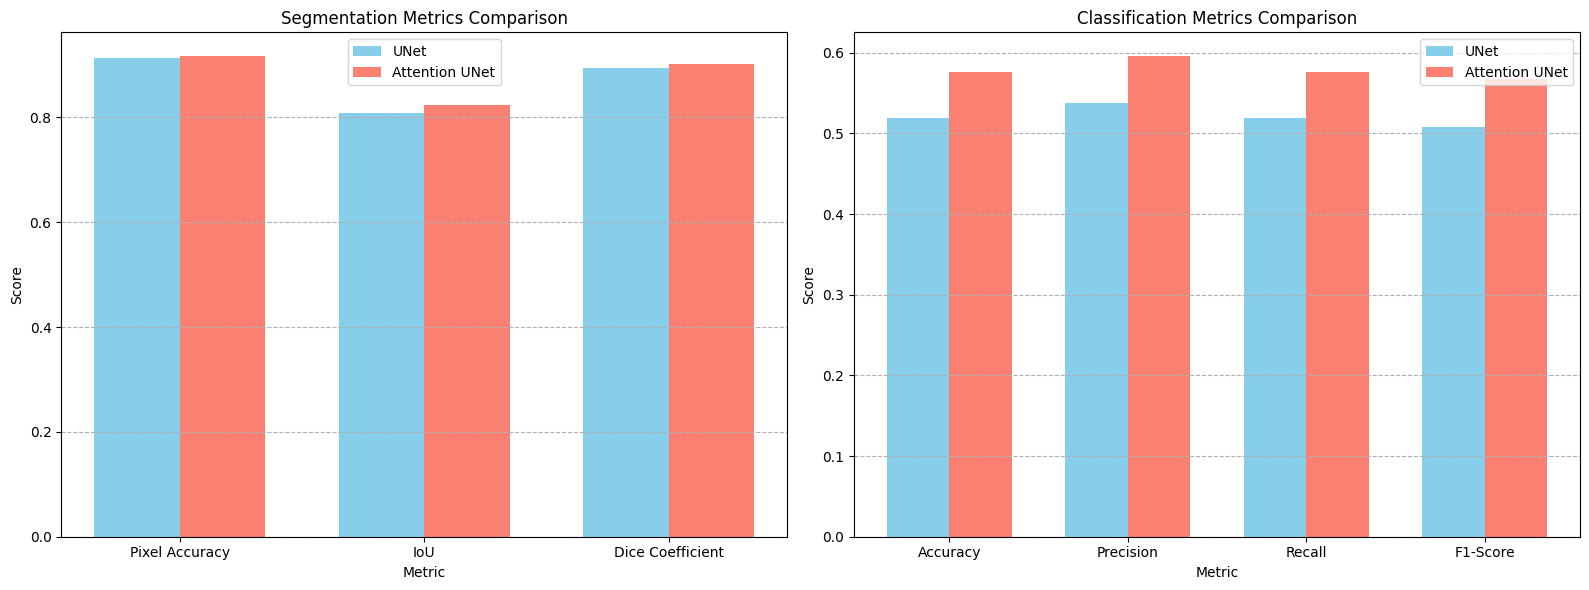

In [ ]:
def plot_test_metrics_comparison(m1_name, m2_name, m1_metrics, m2_metrics):
    metrics_seg = ['test_pixel_acc', 'test_iou', 'test_dice']
    metrics_cls = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1_score']
    metric_labels_seg = ['Pixel Accuracy', 'IoU', 'Dice Coefficient']
    metric_labels_cls = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    m1_values_seg = [m1_metrics[m] for m in metrics_seg]
    m2_values_seg = [m2_metrics[m] for m in metrics_seg]

    m1_values_cls = [m1_metrics[m] for m in metrics_cls]
    m2_values_cls = [m2_metrics[m] for m in metrics_cls]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    bar_width = 0.35
    index_seg = np.arange(len(metrics_seg))
    index_cls = np.arange(len(metrics_cls))

    ax1 = axes[0]
    ax1.bar(index_seg - bar_width/2, m1_values_seg, bar_width, label=m1_name, color='skyblue')
    ax1.bar(index_seg + bar_width/2, m2_values_seg, bar_width, label=m2_name, color='salmon')
    ax1.set_xlabel('Metric')
    ax1.set_ylabel('Score')
    ax1.set_title('Segmentation Metrics Comparison')
    ax1.set_xticks(index_seg)
    ax1.set_xticklabels(metric_labels_seg)
    ax1.legend()
    ax1.grid(axis='y', linestyle='--')

    ax2 = axes[1]
    ax2.bar(index_cls - bar_width/2, m1_values_cls, bar_width, label=m1_name, color='skyblue')
    ax2.bar(index_cls + bar_width/2, m2_values_cls, bar_width, label=m2_name, color='salmon')
    ax2.set_xlabel('Metric')
    ax2.set_ylabel('Score')
    ax2.set_title('Classification Metrics Comparison')
    ax2.set_xticks(index_cls)
    ax2.set_xticklabels(metric_labels_cls)
    ax2.legend()
    ax2.grid(axis='y', linestyle='--')

    plt.tight_layout()
    plt.show()

plot_test_metrics_comparison('UNet', 'Attention UNet', unet_test_metrics, att_unet_test_metrics)

# Bonus Task 2

In [ ]:
# 1. Get unaugmented train and val data

train_dataset_noaug = MyDataset(train_df, transform=val_test_transform)
val_dataset_noaug = MyDataset(val_df, transform=val_test_transform)

# Data Loaders for unaugmented data
train_loader_noaug = DataLoader(
    train_dataset_noaug,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_noaug = DataLoader(
    val_dataset_noaug,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Train dataset (no aug) size: {len(train_dataset_noaug)}")
print(f"Validation dataset (no aug) size: {len(val_dataset_noaug)}")
print(f"Number of batches in train_loader_noaug: {len(train_loader_noaug)}")
print(f"Number of batches in val_loader_noaug: {len(val_loader_noaug)}")

Train dataset (no aug) size: 4090
Validation dataset (no aug) size: 1023
Number of batches in train_loader_noaug: 256
Number of batches in val_loader_noaug: 64


In [ ]:
# 2. Train another UNet model with unaugmented data
model_unet_noaug = UNet().to(device)

optimizer_unet_noaug = optim.AdamW(model_unet_noaug.parameters(), lr=0.001)

seg_loss_func_noaug = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

cls_loss_func_noaug = nn.CrossEntropyLoss(weight=class_weights.to(device))

loss_func_noaug = {
    'segmentation': seg_loss_func_noaug,
    'classification': cls_loss_func_noaug
}

num_epochs_noaug = 30

history_unet_noaug = train_model(
    model_name='unet_noaug',
    model=model_unet_noaug,
    train_loader=train_loader_noaug,
    val_loader=val_loader_noaug,
    optimizer=optimizer_unet_noaug,
    loss_func=loss_func_noaug,
    device=device,
    num_epochs=num_epochs_noaug,
    checkpoint_path=checkpoint_path
)

print("UNet (no augmentation) training complete!")

Epoch 1/30 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/30:
	Segmentation metrics:
		Train Loss: 4.3635 | Train Pixel Acc: 0.6940 | Train IoU: 0.5224 | Train Dice: 0.6838
		Val Loss: 4.3155 | Val Pixel Acc: 0.7235 | Val IoU: 0.5738 | Val Dice: 0.7281
	Classification metrics:
		Train Acc: 0.0417 | Train Prec: 0.0217 | Train Recall: 0.0417 | Train F1: 0.0247
		Val Acc: 0.0420 | Val Prec: 0.0195 | Val Recall: 0.0420 | Val F1: 0.0241
Model saved! Best validation IoU improved to 0.5738


Epoch 2/30 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 29/30:
	Segmentation metrics:
		Train Loss: 0.7105 | Train Pixel Acc: 0.9222 | Train IoU: 0.8326 | Train Dice: 0.9083
		Val Loss: 2.5309 | Val Pixel Acc: 0.9032 | Val IoU: 0.7983 | Val Dice: 0.8872
	Classification metrics:
		Train Acc: 0.8443 | Train Prec: 0.8803 | Train Recall: 0.8443 | Train F1: 0.8516
		Val Acc: 0.4770 | Val Prec: 0.5105 | Val Recall: 0.4770 | Val F1: 0.4697


Epoch 30/30 [Train]:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 30/30:
	Segmentation metrics:
		Train Loss: 0.6124 | Train Pixel Acc: 0.9244 | Train IoU: 0.8367 | Train Dice: 0.9107
		Val Loss: 1.7894 | Val Pixel Acc: 0.9148 | Val IoU: 0.8178 | Val Dice: 0.8994
	Classification metrics:
		Train Acc: 0.8696 | Train Prec: 0.8963 | Train Recall: 0.8696 | Train F1: 0.8741
		Val Acc: 0.5924 | Val Prec: 0.6216 | Val Recall: 0.5924 | Val F1: 0.5871
Model saved! Best validation IoU improved to 0.8178
UNet (no augmentation) training complete!


Testing UNet Model (no augmentation)...


Testing:   0%|          | 0/137 [00:00<?, ?it/s]


--- Test Results ---
Test Loss: 1.8722
Segmentation Metrics:
  Pixel Accuracy: 0.9146
  IoU: 0.8173
  Dice Coefficient: 0.8991
Classification Metrics:
  Accuracy: 0.5607
  Precision: 0.5814
  Recall: 0.5607
  F1-Score: 0.5536

Comparing UNet (augmented) vs UNet (no augmentation)...


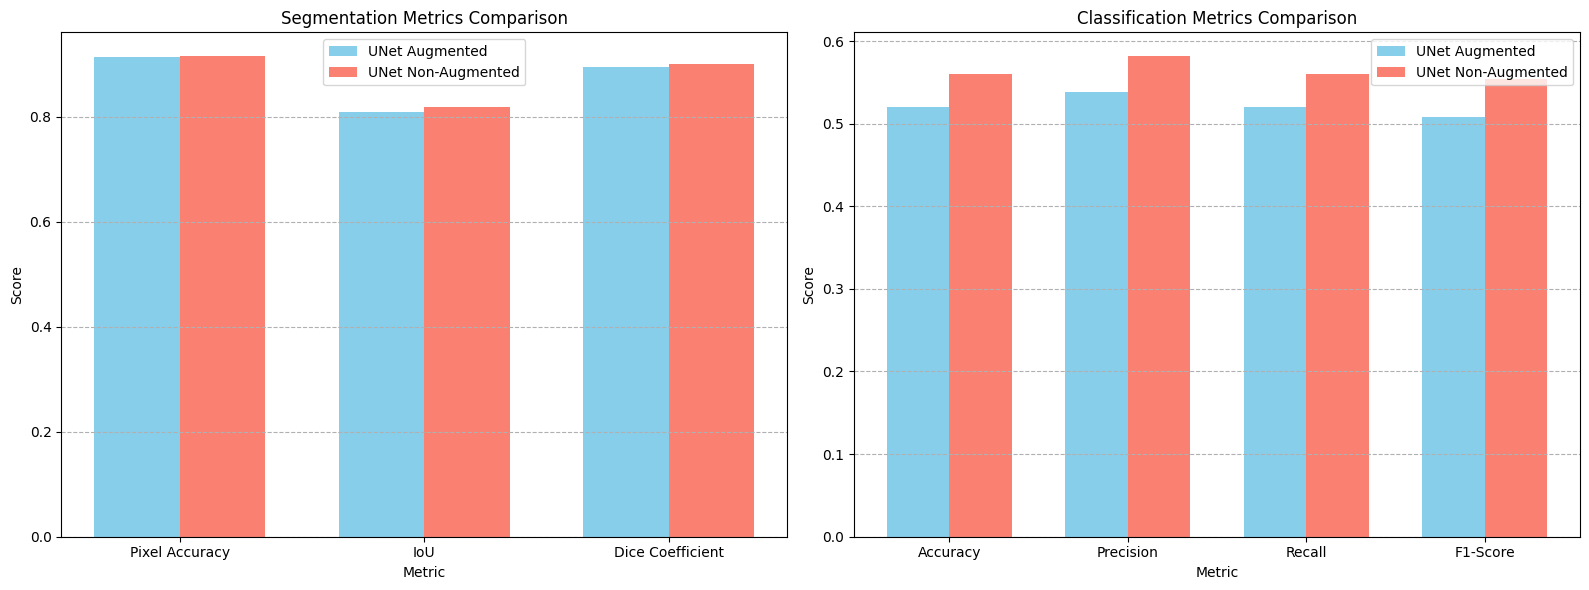

In [ ]:
model_unet_noaug = UNet().to(device)
optimizer_unet_noaug = optim.AdamW(model_unet_noaug.parameters(), lr=0.001)

model_unet_noaug, _ = load_model('unet_noaug', model_unet_noaug, optimizer_unet_noaug, checkpoint_path)

print("Testing UNet Model (no augmentation)...")
unet_noaug_test_metrics = test_model(model_unet_noaug, test_loader, loss_func_noaug, device)

print("\nComparing UNet (augmented) vs UNet (no augmentation)...")
plot_test_metrics_comparison('UNet Augmented', 'UNet Non-Augmented', unet_test_metrics, unet_noaug_test_metrics)

# Bonus Task 4

In [ ]:
model = UNet().to(device)

optimizer = optim.AdamW(model.parameters(), lr=1)

mean_foreground_ratio = 0.418 # From previous EDA result
pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))

loss_func = {
    'segmentation': seg_loss_func,
    'classification': cls_loss_func
}

num_epochs = 10

history_unet = train_model(
    model_name='unet_lr1',
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_func=loss_func,
    device=device,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path
)

print("Training complete!")

Epoch 1/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10:
	Segmentation metrics:
		Train Loss: 15.7799 | Train Pixel Acc: 0.4985 | Train IoU: 0.2154 | Train Dice: 0.3033
		Val Loss: 4.6721 | Val Pixel Acc: 0.4153 | Val IoU: 0.4153 | Val Dice: 0.5861
	Classification metrics:
		Train Acc: 0.0276 | Train Prec: 0.0021 | Train Recall: 0.0276 | Train F1: 0.0035
		Val Acc: 0.0273 | Val Prec: 0.0013 | Val Recall: 0.0273 | Val F1: 0.0025
Model saved! Best validation IoU improved to 0.4153


Epoch 2/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9/10:
	Segmentation metrics:
		Train Loss: 4.6039 | Train Pixel Acc: 0.4967 | Train IoU: 0.2280 | Train Dice: 0.3201
		Val Loss: 4.5486 | Val Pixel Acc: 0.5847 | Val IoU: 0.0000 | Val Dice: 0.0000
	Classification metrics:
		Train Acc: 0.0247 | Train Prec: 0.0015 | Train Recall: 0.0247 | Train F1: 0.0028
		Val Acc: 0.0274 | Val Prec: 0.0015 | Val Recall: 0.0274 | Val F1: 0.0029


Epoch 10/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10:
	Segmentation metrics:
		Train Loss: 4.6087 | Train Pixel Acc: 0.5021 | Train IoU: 0.2033 | Train Dice: 0.2861
		Val Loss: 4.5753 | Val Pixel Acc: 0.5847 | Val IoU: 0.0000 | Val Dice: 0.0000
	Classification metrics:
		Train Acc: 0.0247 | Train Prec: 0.0013 | Train Recall: 0.0247 | Train F1: 0.0025
		Val Acc: 0.0264 | Val Prec: 0.0014 | Val Recall: 0.0264 | Val F1: 0.0027
Training complete!


In [ ]:
model = UNet().to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.1)

mean_foreground_ratio = 0.418
pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))

loss_func = {
    'segmentation': seg_loss_func,
    'classification': cls_loss_func
}

num_epochs = 10

history_unet = train_model(
    model_name='unet_lr01',
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_func=loss_func,
    device=device,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path
)

print("Training complete!")

Epoch 1/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10:
	Segmentation metrics:
		Train Loss: 5.9959 | Train Pixel Acc: 0.4865 | Train IoU: 0.2705 | Train Dice: 0.3804
		Val Loss: 4.4408 | Val Pixel Acc: 0.5847 | Val IoU: 0.0000 | Val Dice: 0.0000
	Classification metrics:
		Train Acc: 0.0200 | Train Prec: 0.0026 | Train Recall: 0.0200 | Train F1: 0.0033
		Val Acc: 0.0274 | Val Prec: 0.0014 | Val Recall: 0.0274 | Val F1: 0.0027
Model saved! Best validation IoU improved to 0.0000


Epoch 2/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9/10:
	Segmentation metrics:
		Train Loss: 4.1587 | Train Pixel Acc: 0.7927 | Train IoU: 0.6240 | Train Dice: 0.7681
		Val Loss: 4.1808 | Val Pixel Acc: 0.7929 | Val IoU: 0.5949 | Val Dice: 0.7457
	Classification metrics:
		Train Acc: 0.0212 | Train Prec: 0.0011 | Train Recall: 0.0212 | Train F1: 0.0020
		Val Acc: 0.0264 | Val Prec: 0.0013 | Val Recall: 0.0264 | Val F1: 0.0025
Model saved! Best validation IoU improved to 0.5949


Epoch 10/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10:
	Segmentation metrics:
		Train Loss: 4.1401 | Train Pixel Acc: 0.8038 | Train IoU: 0.6373 | Train Dice: 0.7781
		Val Loss: 4.1580 | Val Pixel Acc: 0.7938 | Val IoU: 0.6192 | Val Dice: 0.7645
	Classification metrics:
		Train Acc: 0.0264 | Train Prec: 0.0023 | Train Recall: 0.0264 | Train F1: 0.0036
		Val Acc: 0.0264 | Val Prec: 0.0026 | Val Recall: 0.0264 | Val F1: 0.0040
Model saved! Best validation IoU improved to 0.6192
Training complete!


In [ ]:
model = UNet().to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.01)

pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))

loss_func = {
    'segmentation': seg_loss_func,
    'classification': cls_loss_func
}

num_epochs = 10

history_unet_lr001 = train_model(
    model_name='unet_lr001',
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_func=loss_func,
    device=device,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path
)

print("Training complete!")

Epoch 1/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10:
	Segmentation metrics:
		Train Loss: 4.7409 | Train Pixel Acc: 0.6646 | Train IoU: 0.4813 | Train Dice: 0.6429
		Val Loss: 4.3545 | Val Pixel Acc: 0.6501 | Val IoU: 0.5261 | Val Dice: 0.6889
	Classification metrics:
		Train Acc: 0.0251 | Train Prec: 0.0058 | Train Recall: 0.0251 | Train F1: 0.0066
		Val Acc: 0.0264 | Val Prec: 0.0044 | Val Recall: 0.0264 | Val F1: 0.0050
Model saved! Best validation IoU improved to 0.5261


Epoch 2/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9/10:
	Segmentation metrics:
		Train Loss: 3.7848 | Train Pixel Acc: 0.8112 | Train IoU: 0.6439 | Train Dice: 0.7831
		Val Loss: 4.4073 | Val Pixel Acc: 0.7746 | Val IoU: 0.5129 | Val Dice: 0.6774
	Classification metrics:
		Train Acc: 0.0896 | Train Prec: 0.0741 | Train Recall: 0.0896 | Train F1: 0.0706
		Val Acc: 0.0459 | Val Prec: 0.0163 | Val Recall: 0.0459 | Val F1: 0.0194


Epoch 10/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10:
	Segmentation metrics:
		Train Loss: 3.6851 | Train Pixel Acc: 0.8153 | Train IoU: 0.6506 | Train Dice: 0.7879
		Val Loss: 3.8550 | Val Pixel Acc: 0.8007 | Val IoU: 0.5987 | Val Dice: 0.7485
	Classification metrics:
		Train Acc: 0.1128 | Train Prec: 0.0910 | Train Recall: 0.1128 | Train F1: 0.0897
		Val Acc: 0.1065 | Val Prec: 0.0852 | Val Recall: 0.1065 | Val F1: 0.0821
Training complete!


In [ ]:
model = UNet().to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001)

pos_weight_value = torch.tensor((1.0 - mean_foreground_ratio) / mean_foreground_ratio, dtype=torch.float).to(device)
seg_loss_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

cls_loss_func = nn.CrossEntropyLoss(weight=class_weights.to(device))

loss_func = {
    'segmentation': seg_loss_func,
    'classification': cls_loss_func
}

num_epochs = 10

history_unet_lr0001 = train_model(
    model_name='unet_lr0001',
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_func=loss_func,
    device=device,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path
)

print("Training complete!")

Epoch 1/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10:
	Segmentation metrics:
		Train Loss: 4.4486 | Train Pixel Acc: 0.6434 | Train IoU: 0.4573 | Train Dice: 0.6240
		Val Loss: 4.8772 | Val Pixel Acc: 0.7233 | Val IoU: 0.5378 | Val Dice: 0.6990
	Classification metrics:
		Train Acc: 0.0291 | Train Prec: 0.0080 | Train Recall: 0.0291 | Train F1: 0.0101
		Val Acc: 0.0342 | Val Prec: 0.0074 | Val Recall: 0.0342 | Val F1: 0.0098
Model saved! Best validation IoU improved to 0.5378


Epoch 2/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9/10:
	Segmentation metrics:
		Train Loss: 3.1186 | Train Pixel Acc: 0.8479 | Train IoU: 0.7016 | Train Dice: 0.8243
		Val Loss: 3.2526 | Val Pixel Acc: 0.8317 | Val IoU: 0.6908 | Val Dice: 0.8168
	Classification metrics:
		Train Acc: 0.2238 | Train Prec: 0.2425 | Train Recall: 0.2238 | Train F1: 0.2098
		Val Acc: 0.2111 | Val Prec: 0.2145 | Val Recall: 0.2111 | Val F1: 0.1882
Model saved! Best validation IoU improved to 0.6908


Epoch 10/10 [Train]:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10:
	Segmentation metrics:
		Train Loss: 2.9976 | Train Pixel Acc: 0.8516 | Train IoU: 0.7078 | Train Dice: 0.8286
		Val Loss: 4.7792 | Val Pixel Acc: 0.7905 | Val IoU: 0.6415 | Val Dice: 0.7813
	Classification metrics:
		Train Acc: 0.2531 | Train Prec: 0.2742 | Train Recall: 0.2531 | Train F1: 0.2406
		Val Acc: 0.1134 | Val Prec: 0.1221 | Val Recall: 0.1134 | Val F1: 0.0956
Training complete!


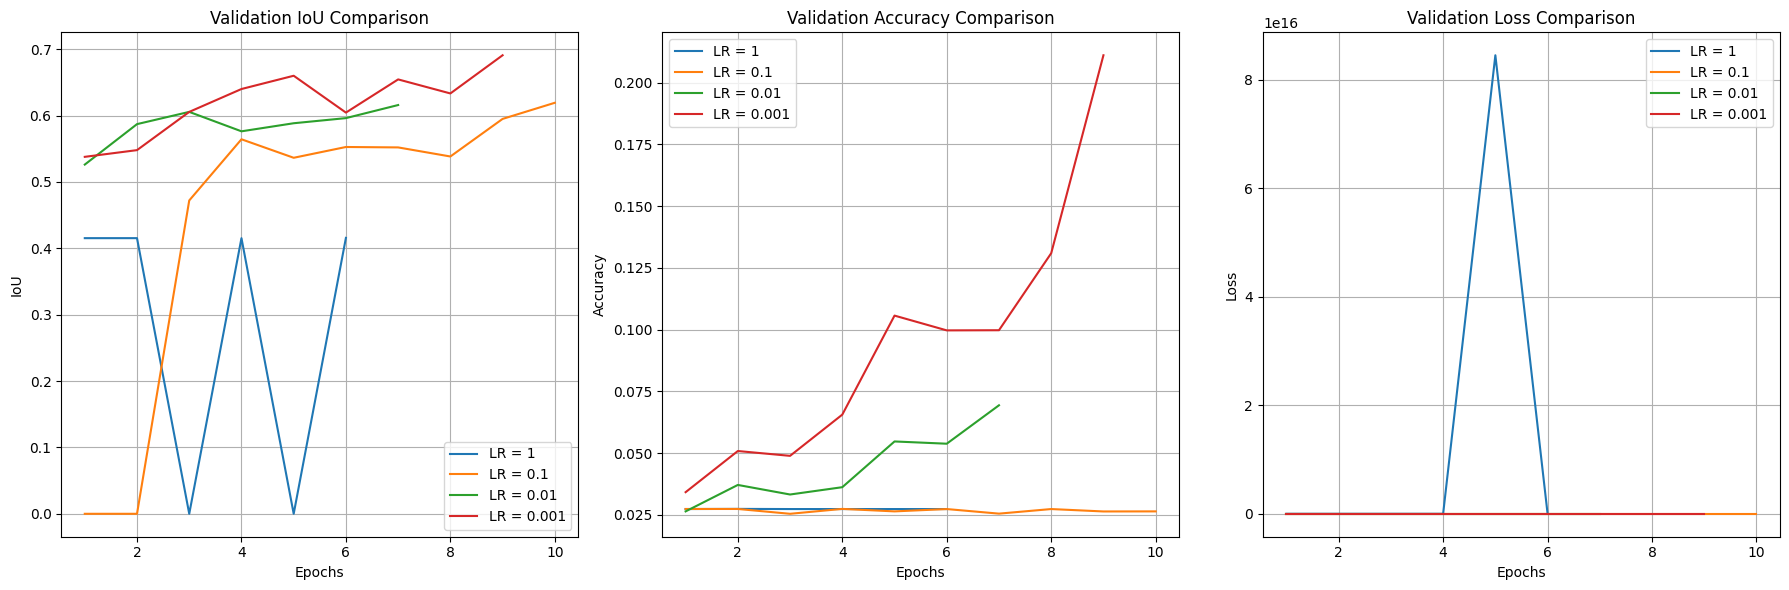

In [ ]:
model_lr1 = UNet().to(device)
optimizer_lr1 = optim.AdamW(model_lr1.parameters(), lr=1)

model_lr01 = UNet().to(device)
optimizer_lr01 = optim.AdamW(model_lr01.parameters(), lr=0.1)

model_lr001 = UNet().to(device)
optimizer_lr001 = optim.AdamW(model_lr001.parameters(), lr=0.01)

model_lr0001 = UNet().to(device)
optimizer_lr0001 = optim.AdamW(model_lr0001.parameters(), lr=0.001)

_, history_lr1 = load_model('unet_lr1', model_lr1, optimizer_lr1, checkpoint_path)
_, history_lr01 = load_model('unet_lr01', model_lr01, optimizer_lr01, checkpoint_path)
_, history_lr001 = load_model('unet_lr001', model_lr001, optimizer_lr001, checkpoint_path)
_, history_lr0001 = load_model('unet_lr0001', model_lr0001, optimizer_lr0001, checkpoint_path)

def plot_lr_comparison(histories, learning_rates):
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    for lr, history in zip(learning_rates, histories):
        epochs = range(1, len(history['val_ious']) + 1)
        plt.plot(epochs, history['val_ious'], label=f'LR = {lr}')
    plt.title('Validation IoU Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    for lr, history in zip(learning_rates, histories):
        epochs = range(1, len(history['val_accuracies']) + 1)
        plt.plot(epochs, history['val_accuracies'], label=f'LR = {lr}')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    for lr, history in zip(learning_rates, histories):
        epochs = range(1, len(history['val_losses']) + 1)
        plt.plot(epochs, history['val_losses'], label=f'LR = {lr}')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

all_histories = [history_lr1, history_lr01, history_lr001, history_lr0001]
all_lrs = [1, 0.1, 0.01, 0.001]

plot_lr_comparison(all_histories, all_lrs)

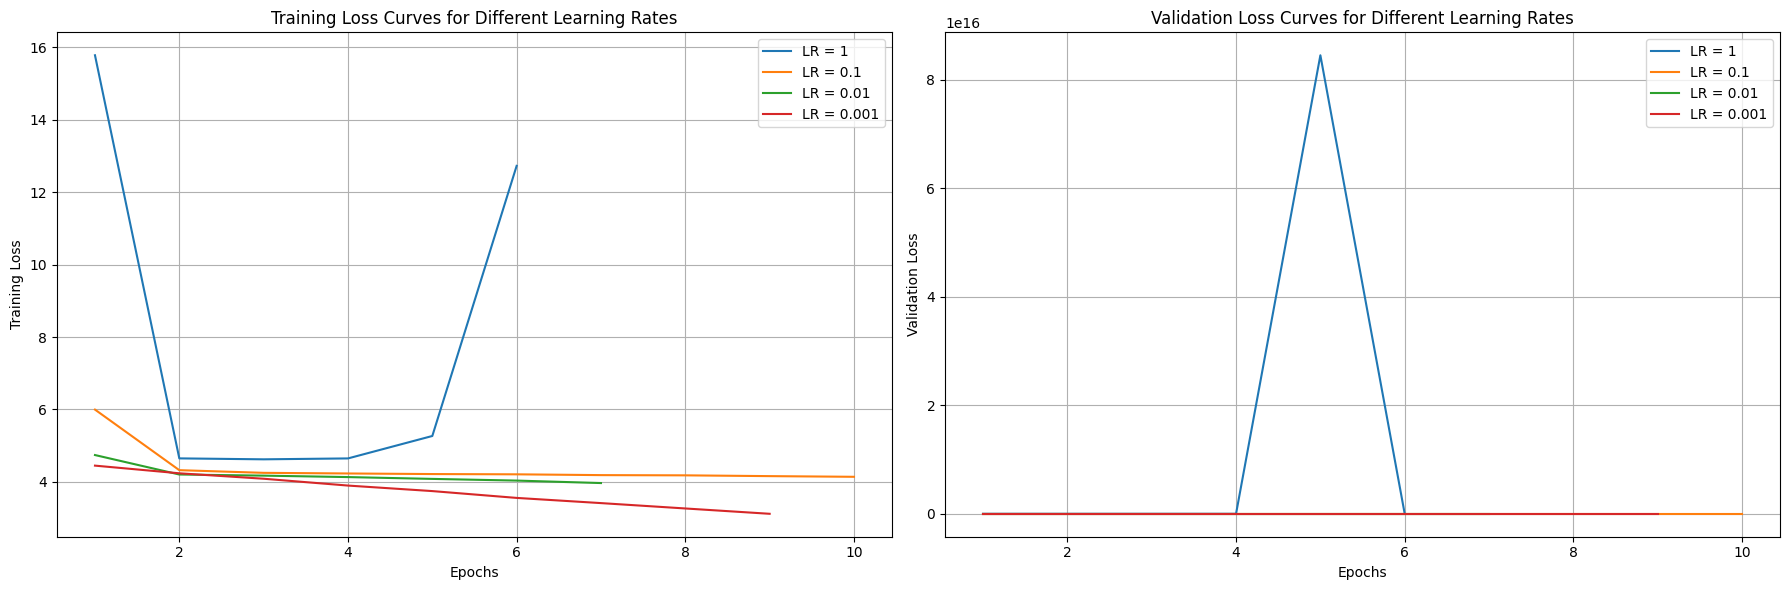

In [ ]:
def plot_loss_curve_comparison(histories, learning_rates):
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 2, 1)
    for lr, history in zip(learning_rates, histories):
        epochs = range(1, len(history['train_losses']) + 1)
        plt.plot(epochs, history['train_losses'], label=f'LR = {lr}')
    plt.title('Training Loss Curves for Different Learning Rates')
    plt.xlabel('Epochs')
    plt.ylabel('Training Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for lr, history in zip(learning_rates, histories):
        epochs = range(1, len(history['val_losses']) + 1)
        plt.plot(epochs, history['val_losses'], label=f'LR = {lr}')
    plt.title('Validation Loss Curves for Different Learning Rates')
    plt.xlabel('Epochs')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_loss_curve_comparison(all_histories, all_lrs)